In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.load_data import load_ai4i_dataset

from src.features.feature_engineering import (
    create_engineered_features
)

from src.features.preprocessing import (
    prepare_modeling_dataset
)

from src.models.train_baseline import (
    build_baseline_model
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference,Power Proxy,Mechanical Stress Index,Thermal Stress Index,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.027595,449.40,0,0,1
1,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0.032884,486.15,0,1,0
2,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0.032977,513.76,0,1,0
3,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0.027565,410.80,0,1,0
4,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0.028409,420.00,0,1,0


In [3]:
X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]

In [4]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

In [5]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())

print(y_test.value_counts())

(8000, 12)
(2000, 12)
Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [6]:
model = build_baseline_model()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [7]:
y_pred = model.predict(
    X_test
)

y_prob = model.predict_proba(
    X_test
)[:, 1]

In [9]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        y_pred
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

Accuracy: 0.9685
Precision: 0.6
Recall: 0.22058823529411764
F1: 0.3225806451612903
ROC AUC: 0.9295609548167093


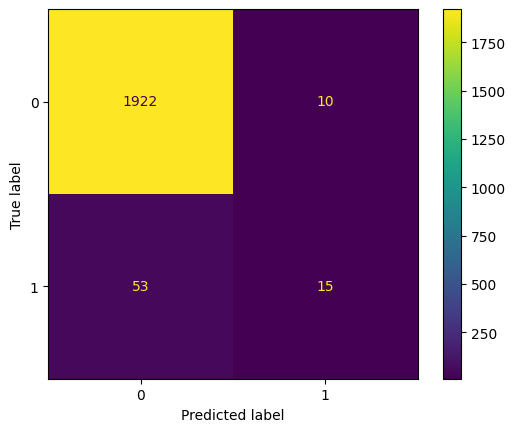

In [10]:
cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    cm
).plot()

plt.show()

Experiment 1 Findings

Baseline Logistic Regression achieved high accuracy (96.85%) and strong ROC-AUC (0.93).

However, recall was only 22.1%, meaning the model detected only 15 of 68 failures in the test set.

The model produced very few false positives but missed a large number of actual failures.

For predictive maintenance, false negatives are more costly than false positives, indicating the need for imbalance-aware modeling strategies.

## Experiment 2: Balanced Logistic Regression

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.load_data import load_ai4i_dataset

from src.features.feature_engineering import (
    create_engineered_features
)

from src.features.preprocessing import (
    prepare_modeling_dataset
)

from src.models.train_baseline import (
    build_balanced_model
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference,Power Proxy,Mechanical Stress Index,Thermal Stress Index,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.027595,449.40,0,0,1
1,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0.032884,486.15,0,1,0
2,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0.032977,513.76,0,1,0
3,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0.027565,410.80,0,1,0
4,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0.028409,420.00,0,1,0


In [3]:
X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())

print(y_test.value_counts())

(8000, 12)
(2000, 12)
Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [4]:
model = build_balanced_model()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Accuracy: 0.857
Precision: 0.1716867469879518
Recall: 0.8382352941176471
F1: 0.285
ROC AUC: 0.9331080258190232


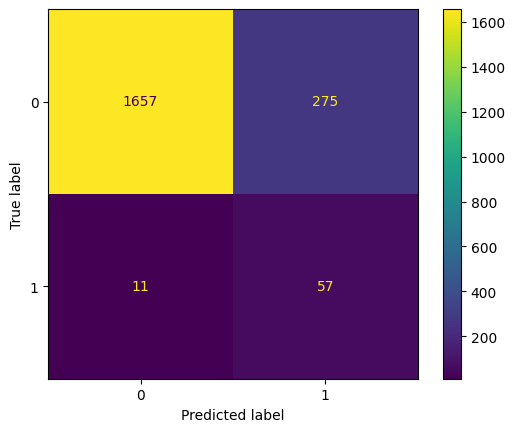

In [5]:
y_pred = model.predict(
    X_test
)

y_prob = model.predict_proba(
    X_test
)[:, 1]

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        y_pred
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    cm
).plot()

plt.show()

Experiment 2 Findings

Applying class weighting significantly increased recall from 22.1% to 83.8%.

The number of missed failures decreased from 53 to 11.

This improvement came at the cost of increased false positives, reducing precision from 60.0% to 17.2%.

For predictive maintenance applications, where missing failures is often more expensive than generating additional inspections, the balanced model is preferable to the baseline model.

ROC-AUC remained high (~0.93), indicating good class separability despite the class imbalance.

## Experiment 3: Threshold Tuning

Objective:
Evaluate the impact of different decision thresholds on precision, recall, and F1-score.

Since predictive maintenance prioritizes failure detection, lower thresholds may improve recall at the expense of precision.

The balanced logistic regression model is used as the probability estimator.

In [7]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression


# Train balanced logistic regression
balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

balanced_model.fit(X_train, y_train)

# Failure probabilities
y_prob = balanced_model.predict_proba(X_test)[:, 1]

# Thresholds to evaluate
thresholds = [0.50, 0.40, 0.30, 0.20]

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        ),
        "False Positives": confusion_matrix(
            y_test,
            y_pred_threshold
        )[0, 1],
        "False Negatives": confusion_matrix(
            y_test,
            y_pred_threshold
        )[1, 0]
    })

results_df = pd.DataFrame(results)

results_df

,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives
0,0.5,0.857,0.171687,0.838235,0.285000,275,11
1,0.4,0.815,0.138756,0.852941,0.238683,360,10
2,0.3,0.753,0.114130,0.926471,0.203226,489,5
3,0.2,0.657,0.088000,0.970588,0.161369,684,2


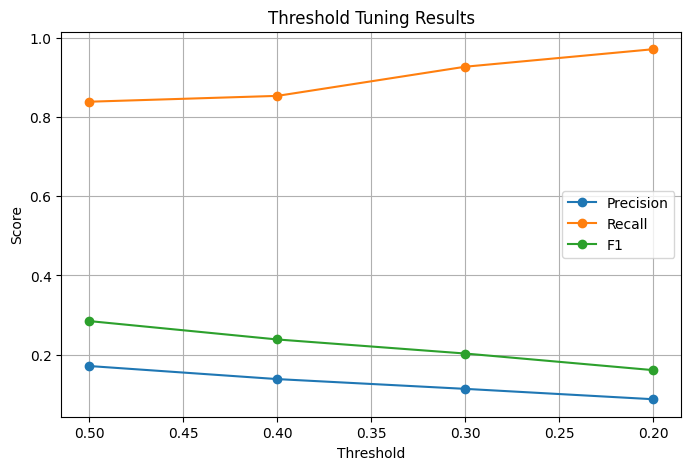

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    results_df["Threshold"],
    results_df["F1"],
    marker="o",
    label="F1"
)

plt.gca().invert_xaxis()

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Results")

plt.legend()

plt.grid(True)

plt.show()

Threshold Tuning Findings

Reducing the classification threshold significantly increased recall, reducing missed failures from 11 to 2.

This improvement came at the cost of additional false positives.

For predictive maintenance applications, threshold selection should be based on operational cost rather than accuracy alone.

Future work will incorporate explicit cost-sensitive evaluation.